# lr_code

La Regresión Lineal es un modelo multivariante de referencia e interpretable. Estima una relación lineal entre las variables predictoras creadas y las pernoctaciones. La estandarización de las variables permite comparar más fácilmente sus pesos relativos, aunque el tamaño reducido de la muestra y la correlación entre predictores siguen siendo aspectos importantes.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install scikit-learn matplotlib pandas numpy


>> Comparando OLS vs Ridge (validación cruzada temporal)...


/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.03708e-16): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.41189e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.13714e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.11893e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.53272e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

Mejor alpha (Ridge): 1000.000

MAE medio en CV - OLS puro:  1,121,952
MAE medio en CV - Ridge:     394,452
-> Se selecciona Ridge (mejor generalización en CV)


      MÉTRICAS REGRESIÓN LINEAL (TEST)
MAE:  230,698 pernoctaciones
RMSE: 278,004
MAPE: 7.96%
R2:   0.8715



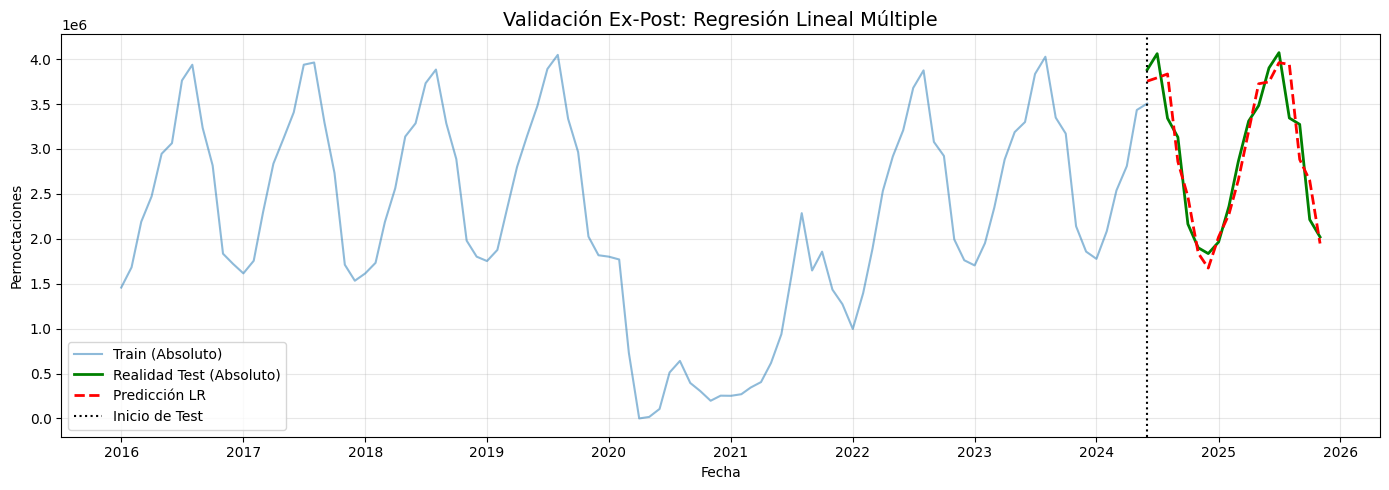

 PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)
Umbral Verde/Naranja: 1,834,345 pernoctaciones
Umbral Naranja/Rojo:  3,018,909 pernoctaciones
Aciertos de nivel de alerta: 83.3% (15/18 meses)

fecha_objetivo  pernoctaciones_real  pernoctaciones_predicha ipt_real  codigo_real ipt_predicho  codigo_predicho  acierto_nivel
    2024-06-01            3881922.0             3.754941e+06     Rojo            2         Rojo                2           True
    2024-07-01            4061207.0             3.792629e+06     Rojo            2         Rojo                2           True
    2024-08-01            3341674.0             3.834932e+06     Rojo            2         Rojo                2           True
    2024-09-01            3130930.0             2.859148e+06     Rojo            2      Naranja                1          False
    2024-10-01            2164179.0             2.467797e+06  Naranja            1      Naranja                1           True
    2024-11-01            1900241.0       

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. CARGA DE DATOS
RUTA_DATOS = "/content/drive/MyDrive/VIU/TFM/Data/DATASET_TFM_FINAL.csv"
TARGET = "Pernoctaciones"
HORIZONTE = 1     # meses de antelación
MESES_TEST = 18   # ventana de test

df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha"], index_col="fecha")
df = df.sort_index()
y_abs = df[TARGET]


# Safe features
df["pernoctaciones_lag_1"] = y_abs.shift(1)
df["pernoctaciones_lag_2"] = y_abs.shift(2)
df["pernoctaciones_lag_3"] = y_abs.shift(3)
df["pernoctaciones_roll_mean_3"] = y_abs.shift(1).rolling(3).mean()
df["pernoctaciones_roll_mean_12"] = y_abs.shift(1).rolling(12).mean()
df["pernoctaciones_roll_std_3"] = y_abs.shift(1).rolling(3).std()
df["pernoctaciones_ewm_12"] = y_abs.shift(1).ewm(span=12, adjust=False).mean()
df["yoy_growth_lag1"] = y_abs.pct_change(12).shift(1).replace([np.inf, -np.inf], np.nan)
df["pernoctaciones_diff_lag_1"] = y_abs.diff().shift(1)

SAFE_FEATURES = [
    "mes_sin", "mes_cos", "es_festivo", "es_fin_semana", "dia_libre_real", "es_covid",
    "pernoctaciones_lag_1", "pernoctaciones_lag_2", "pernoctaciones_lag_3",
    "pernoctaciones_roll_mean_3", "pernoctaciones_roll_mean_12",
    "pernoctaciones_roll_std_3", "pernoctaciones_ewm_12", "yoy_growth_lag1",
    "pernoctaciones_diff_lag_1",
    "llegadas_lag_1", "llegadas_lag_2",
    "barcelona flights_lag_1", "barcelona flights_lag_2",
    "barcelona hotel_lag_1", "barcelona hotel_lag_2",
    "airbnb barcelona_lag_1", "airbnb barcelona_lag_2",
]


def build_dataset_diff(data, h, features, target=TARGET):
    """X (features seguras en t) e y_diff = valor absoluto(t+h) - valor absoluto(t).
    El shift(-h) se calcula ANTES del dropna para no desalinear las fechas."""
    d = data.copy()
    d["y_abs_objetivo"] = d[target].shift(-h)
    d["y_diff_h"] = d["y_abs_objetivo"] - d[target]
    d = d.dropna(subset=features + ["y_diff_h"])
    X = d[features]
    y_diff = d["y_diff_h"]
    y_abs_ancla = d[target]
    y_abs_objetivo = d["y_abs_objetivo"]
    return X, y_diff, y_abs_ancla, y_abs_objetivo


X, y_diff, y_abs_ancla, y_abs_obj = build_dataset_diff(df, HORIZONTE, SAFE_FEATURES)

X_train, X_test = X.iloc[:-MESES_TEST], X.iloc[-MESES_TEST:]
y_train_diff, y_test_diff = y_diff.iloc[:-MESES_TEST], y_diff.iloc[-MESES_TEST:]
y_test_abs = y_abs_obj.iloc[-MESES_TEST:]
y_ancla_test = y_abs_ancla.iloc[-MESES_TEST:]


# 2. OLS vs RIDGE (sustituye a la doble optimización de XGBoost/RF)
# La Regresión Lineal pura no tiene hiperparámetros que buscar. En su lugar, comprobamos aquí si la regularización L2 (Ridge) mejora sobre el OLS puro usando validación cruzada temporal (TimeSeriesSplit) para elegir el alpha.
# Con 21 variables y ~100 observaciones de entrenamiento, la multicolinealidad entre lags/rolling stats hace que Ridge sea razonable de comprobar.
tscv = TimeSeriesSplit(n_splits=4)

print(">> Comparando OLS vs Ridge (validación cruzada temporal)...")
modelo_ols = LinearRegression()
modelo_ols.fit(X_train, y_train_diff)

alphas_candidatos = np.logspace(-2, 3, 30)
modelo_ridge = RidgeCV(alphas=alphas_candidatos, cv=tscv, scoring="neg_mean_absolute_error")
modelo_ridge.fit(X_train, y_train_diff)

print(f"Mejor alpha (Ridge): {modelo_ridge.alpha_:.3f}\n")

# Evaluamos ambos en el propio train con CV para decidir cuál usar en test
from sklearn.model_selection import cross_val_score
mae_cv_ols = -cross_val_score(LinearRegression(), X_train, y_train_diff, cv=tscv, scoring="neg_mean_absolute_error").mean()
mae_cv_ridge = -cross_val_score(RidgeCV(alphas=[modelo_ridge.alpha_]), X_train, y_train_diff, cv=tscv, scoring="neg_mean_absolute_error").mean()

print(f"MAE medio en CV - OLS puro:  {mae_cv_ols:,.0f}")
print(f"MAE medio en CV - Ridge:     {mae_cv_ridge:,.0f}")

if mae_cv_ridge < mae_cv_ols:
    modelo_lr_opt = modelo_ridge
    nombre_modelo = f"Ridge (alpha={modelo_ridge.alpha_:.2f})"
    print("-> Se selecciona Ridge (mejor generalización en CV)\n")
else:
    modelo_lr_opt = modelo_ols
    nombre_modelo = "OLS (Regresión Lineal pura)"
    print("-> Se selecciona OLS puro (Ridge no mejora la generalización)\n")

# 3. PREDICCIÓN Y RECONSTRUCCIÓN MATEMÁTICA
predicciones_diff = pd.Series(modelo_lr_opt.predict(X_test), index=y_test_diff.index)
predicciones_abs = y_ancla_test + predicciones_diff


# 4. MÉTRICAS DE EVALUACIÓN FINAL
mae = mean_absolute_error(y_test_abs, predicciones_abs)
rmse = np.sqrt(mean_squared_error(y_test_abs, predicciones_abs))
mape = np.mean(np.abs((y_test_abs - predicciones_abs) / y_test_abs)) * 100
r2 = r2_score(y_test_abs, predicciones_abs)

print("\n" + "="*40)
print("      MÉTRICAS REGRESIÓN LINEAL (TEST)")
print("="*40)
print(f"MAE:  {mae:,.0f} pernoctaciones")
print(f"RMSE: {rmse:,.0f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2:   {r2:.4f}\n")

# 5. VISUALIZACIÓN
plt.figure(figsize=(14, 5))
plt.plot(y_abs.iloc[:-MESES_TEST].index, y_abs.iloc[:-MESES_TEST],
          label="Train (Absoluto)", color="#1f77b4", alpha=0.5)
plt.plot(y_test_abs.index, y_test_abs, label="Realidad Test (Absoluto)",
          color="green", linewidth=2)
plt.plot(predicciones_abs.index, predicciones_abs,
          label='Predicción LR', color='red', linestyle='--', linewidth=2)
plt.axvline(x=y_test_abs.index[0], color='black', linestyle=':', label='Inicio de Test')
plt.title('Validación Ex-Post: Regresión Lineal Múltiple', fontsize=14)
plt.ylabel('Pernoctaciones')
plt.xlabel('Fecha')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("lr_h1_ipt_final.png", dpi=110)
plt.show()

# 6. ÍNDICE DE PRESIÓN TURÍSTICA (IPT) - 3 NIVELES DE ALERTA
# Verde   -> presión turística baja/moderada (nivel menos grave)
# Naranja -> presión turística alta (nivel intermedio)
# Rojo    -> presión turística muy alta / saturación (nivel más grave)

# Mismos umbrales (P33/P66 del histórico completo) que en XGBoost y Random
# Forest, para que los tres modelos sean directamente comparables.
UMBRAL_VERDE_NARANJA, UMBRAL_NARANJA_ROJO = np.percentile(y_abs, [33, 66])

NIVELES_IPT = {
    0: "Verde",
    1: "Naranja",
    2: "Rojo",
}


def clasificar_ipt(valor_pernoctaciones):
    """Devuelve (nivel_texto, codigo_numerico) donde 0=Verde (menos grave)
    y 2=Rojo (más grave)."""
    if valor_pernoctaciones < UMBRAL_VERDE_NARANJA:
        codigo = 0
    elif valor_pernoctaciones < UMBRAL_NARANJA_ROJO:
        codigo = 1
    else:
        codigo = 2
    return NIVELES_IPT[codigo], codigo


# 6.1 Alertas IPT sobre todo el conjunto de test
alertas_test = pd.DataFrame({
    "fecha_objetivo": y_test_abs.index,
    "pernoctaciones_real": y_test_abs.values,
    "pernoctaciones_predicha": predicciones_abs.values,
})
alertas_test[["ipt_real", "codigo_real"]] = alertas_test["pernoctaciones_real"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test[["ipt_predicho", "codigo_predicho"]] = alertas_test["pernoctaciones_predicha"].apply(
    lambda v: pd.Series(clasificar_ipt(v))
)
alertas_test["acierto_nivel"] = alertas_test["codigo_real"] == alertas_test["codigo_predicho"]

precision_semaforo = alertas_test["acierto_nivel"].mean() * 100
print("=" * 45)
print(" PRECISIÓN DE LA CLASIFICACIÓN SEMÁFORO (IPT)")
print("=" * 45)
print(f"Umbral Verde/Naranja: {UMBRAL_VERDE_NARANJA:,.0f} pernoctaciones")
print(f"Umbral Naranja/Rojo:  {UMBRAL_NARANJA_ROJO:,.0f} pernoctaciones")
print(f"Aciertos de nivel de alerta: {precision_semaforo:.1f}% ({alertas_test['acierto_nivel'].sum()}/{len(alertas_test)} meses)\n")
print(alertas_test.to_string(index=False))


# 6.2 Matriz de confusión simple entre niveles
matriz_confusion = pd.crosstab(
    alertas_test["ipt_real"], alertas_test["ipt_predicho"],
    rownames=["Real"], colnames=["Predicho"]
).reindex(index=["Verde", "Naranja", "Rojo"], columns=["Verde", "Naranja", "Rojo"], fill_value=0)
print("\nMatriz de confusión (niveles IPT):")
print(matriz_confusion)

# 6.3 Coeficientes del modelo (equivalente lineal a la "importancia de variables" de los modelos de árboles). Se estandarizan las variables para que los coeficientes sean comparables entre sí.
X_train_std = (X_train - X_train.mean()) / X_train.std()
modelo_coef = type(modelo_lr_opt)(**modelo_lr_opt.get_params()) if hasattr(modelo_lr_opt, "get_params") else modelo_lr_opt
if isinstance(modelo_lr_opt, RidgeCV):
    from sklearn.linear_model import Ridge
    modelo_coef = Ridge(alpha=modelo_lr_opt.alpha_)
else:
    modelo_coef = LinearRegression()
modelo_coef.fit(X_train_std, y_train_diff)

coeficientes = pd.Series(modelo_coef.coef_, index=SAFE_FEATURES).sort_values(key=abs, ascending=False)
print(f"\nCoeficientes estandarizados ({nombre_modelo}, top 10 por magnitud):")
print(coeficientes.head(10).to_string())

# 7. EXPORTAR RESULTADOS
resumen_metrico = pd.DataFrame([{
    "Modelo": nombre_modelo,
    "Horizonte (meses)": HORIZONTE,
    "MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2,
    "Precision_semaforo (%)": precision_semaforo,
}])
resumen_metrico.to_csv("resultados_lr_ipt_h1.csv", index=False)
alertas_test.to_csv("alertas_ipt_h1_test_lr.csv", index=False)
matriz_confusion.to_csv("matriz_confusion_ipt_h1_lr.csv")
coeficientes.to_csv("coeficientes_lr_h1.csv", header=["coeficiente_estandarizado"])

print("\nArchivos exportados: resultados_lr_ipt_h1.csv, alertas_ipt_h1_test_lr.csv, "
      "matriz_confusion_ipt_h1_lr.csv, coeficientes_lr_h1.csv, lr_h1_ipt_final.png")
